In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# DATA UPLOAD

In [4]:
print("Loading the filtered Italian dataset...")
df = pd.read_csv("data/INGV/italy_earthquakes_1985_2025.csv")

df['time'] = pd.to_datetime(df['time'], utc=True)
df['year'] = df['time'].dt.year

print(f"Dataset ready: {len(df)} earthquakes loaded.")

Loading the filtered Italian dataset...
Dataset ready: 215679 earthquakes loaded.


# Original DB columns parameters:

- **EventID** ID assigned by the data center, as to be used with eventid parameter
- **Time** Origin time of the event in UTC
- **Latitude** Event latitude in degrees
- **Longitude** Event longitude in degrees
- **Depth/km** Event depth in kilometers
- **Author** Identifier of event origin author
- **Catalog** Identifier of source catalog
- **Contributor** Identifier of event information contributor
- **ContributorID** Event ID as reported by the contributor
- **MagType** Magnitude scale identifier (e.g. mb, ML, Mw)
- **Magnitude** Magnitude value
- **MagAuthor** Identifier of magnitude author
- **EventLocationName** Geographic description of event location (e.g. Flinn-Engdahl region name)
- **EventType** Event type classification string as of QuakeML 1.2 EventType enumeration

# ***Check of filtered DB***

In [5]:
print(f"The uploaded dataframe has {len(df):_} rows and {len(df.columns):_} columns.")
memory = df.memory_usage(deep=True).sum() / (1024 ** 2)
print(f"It occupies {memory:_.2f} MB in RAM memory")
print(df.columns)
display( pd.concat([df.head(5),df.tail(5)]) )

The uploaded dataframe has 215_679 rows and 6 columns.
It occupies 9.05 MB in RAM memory
Index(['time', 'latitude', 'longitude', 'depth_km', 'magnitude', 'year'], dtype='str')


,time,latitude,longitude,depth_km,magnitude,year
0,1985-01-31 13:57:02.820000+00:00,38.7210,21.5560,10.0,3.8,1985
1,1985-01-28 08:45:53.200000+00:00,42.5150,13.3130,10.0,2.5,1985
2,1985-01-27 03:24:43.880000+00:00,40.7590,15.2500,10.0,2.9,1985
3,1985-01-25 23:33:12.210000+00:00,39.1350,16.0000,99.7,3.1,1985
4,1985-01-25 22:26:11.110000+00:00,40.5710,19.3100,10.0,2.8,1985
215674,2025-12-01 10:35:34.450000+00:00,45.8927,11.9652,7.8,1.5,2025
215675,2025-12-01 07:12:13+00:00,42.7787,12.7258,10.4,1.9,2025
215676,2025-12-01 03:10:19.730000+00:00,45.8738,7.0510,11.1,1.6,2025
215677,2025-12-01 02:25:48.990000+00:00,44.1677,9.9072,6.4,1.7,2025
215678,2025-12-01 01:27:50.160000+00:00,44.5130,10.2288,25.0,2.4,2025


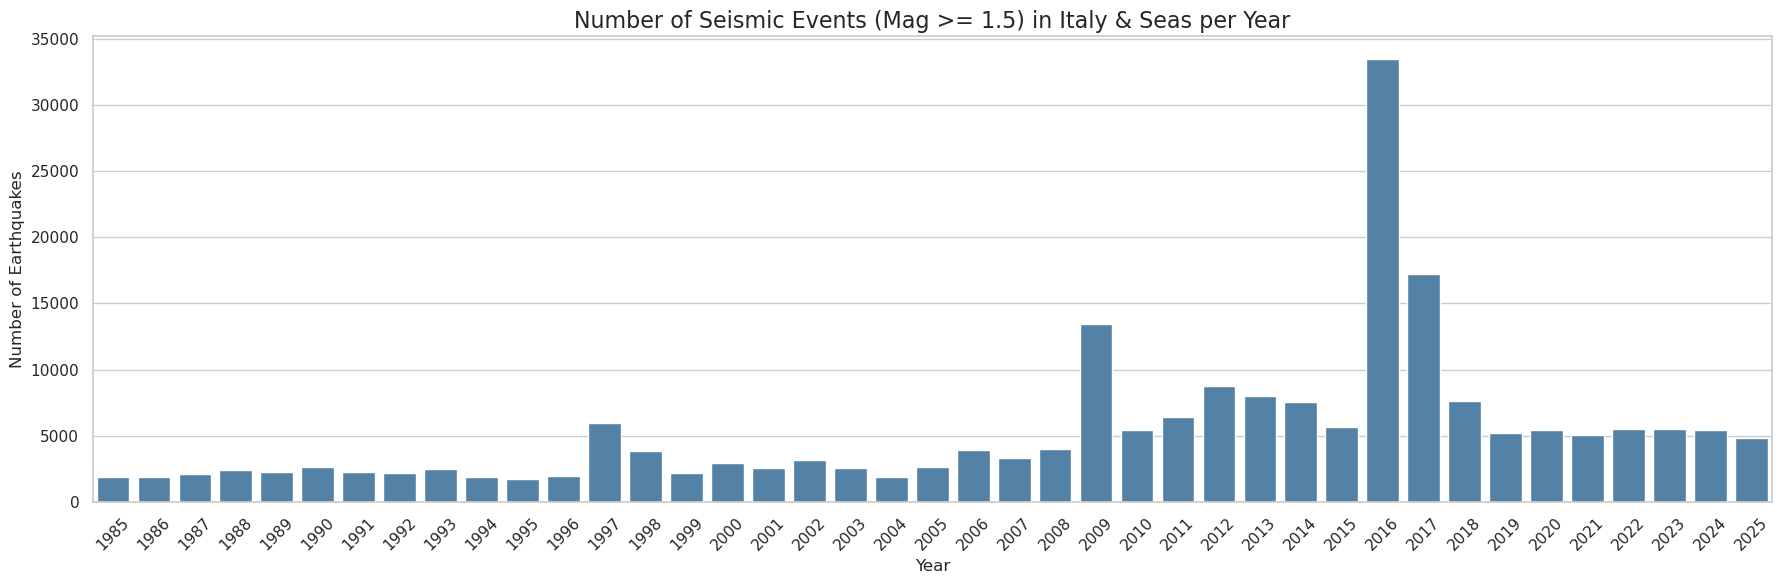

In [6]:
sns.set_theme(style="whitegrid")
%matplotlib inline



# Earthquake Frequency Over Time
plt.figure(figsize=(18, 6))
year_counts = df['year'].value_counts().sort_index()
sns.barplot(x=year_counts.index, y=year_counts.values, color='steelblue')
plt.xticks(rotation=45)
plt.title('Number of Seismic Events (Mag >= 1.5) in Italy & Seas per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Number of Earthquakes')
plt.tight_layout()
plt.show()

/tmp/ipykernel_26793/2979434455.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')


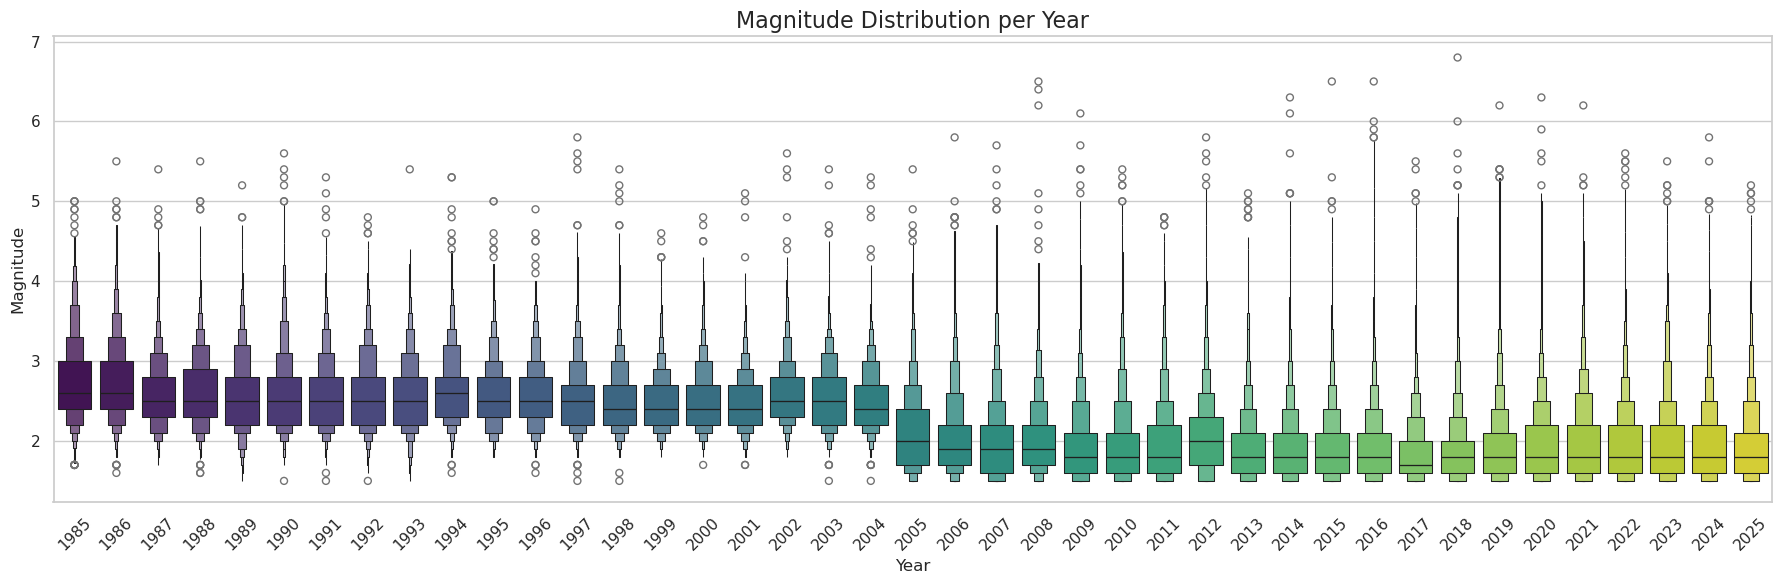

In [7]:
# Magnitude Distribution per Year
plt.figure(figsize=(18, 6))
sns.boxenplot(data=df, x='year', y='magnitude', palette='viridis')
plt.xticks(rotation=45)
plt.title('Magnitude Distribution per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

/tmp/ipykernel_26793/4236896096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='year', y='depth_km', palette='magma')


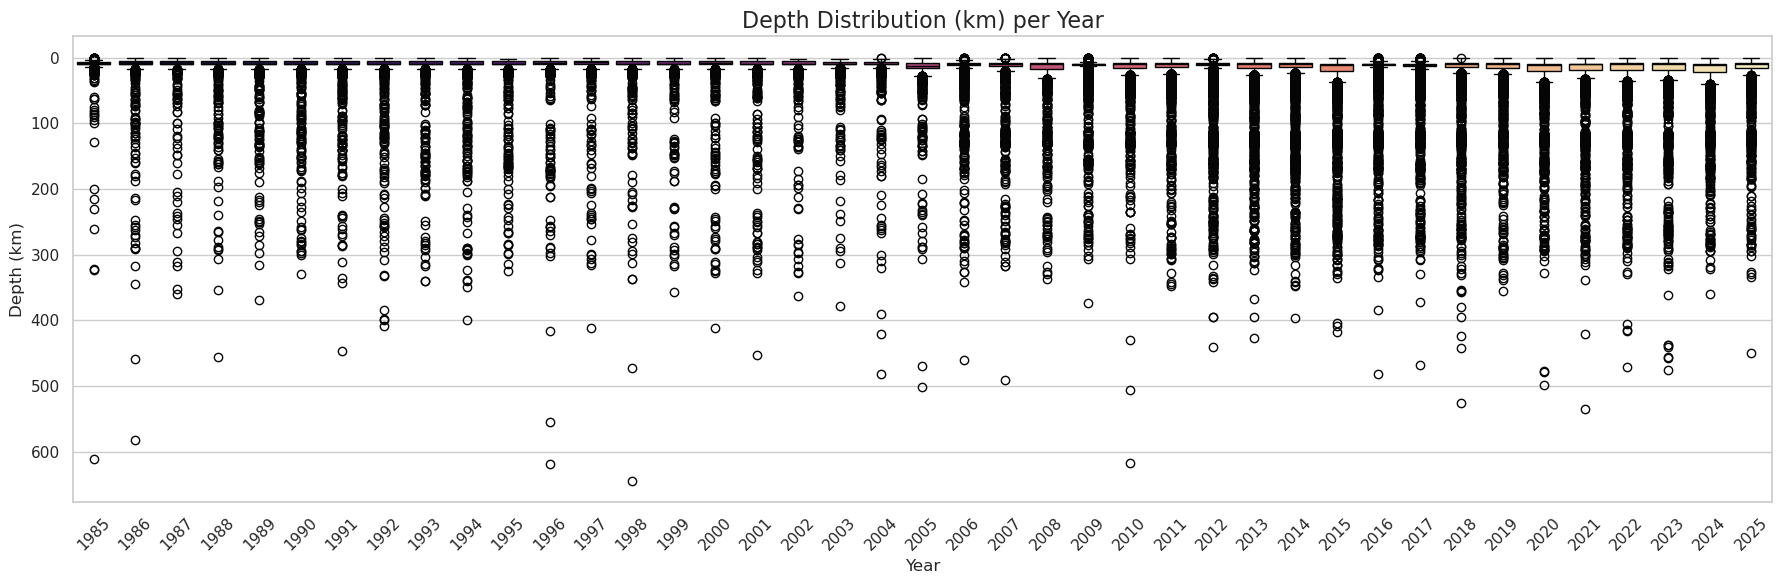

/tmp/ipykernel_26793/4236896096.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['depth_km'] <= 40], x='year', y='depth_km', palette='magma')


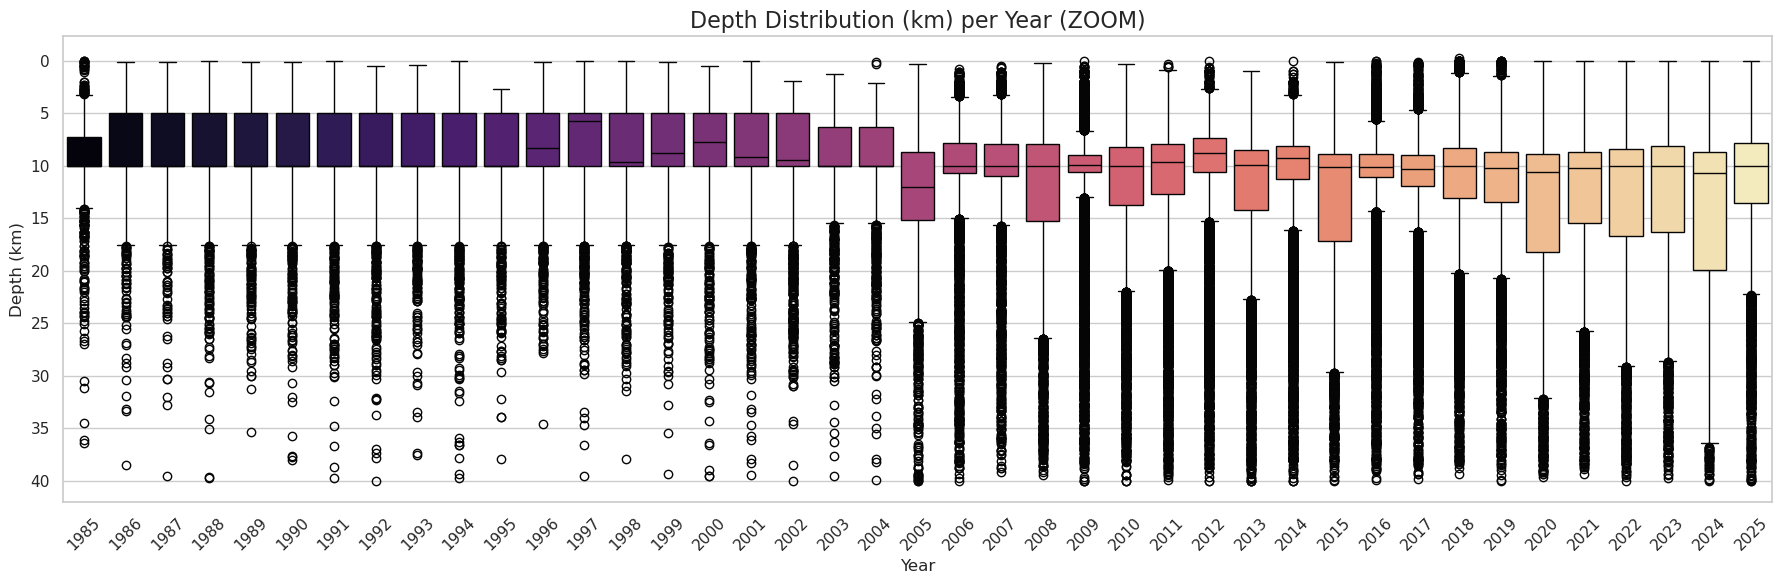

In [12]:
# Depth Distribution per Year
plt.figure(figsize=(18, 6))
sns.boxplot(data=df, x='year', y='depth_km', palette='magma')
plt.gca().invert_yaxis() 
plt.xticks(rotation=45)
plt.title('Depth Distribution (km) per Year', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Depth (km)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
sns.boxplot(data=df[df['depth_km'] <= 40], x='year', y='depth_km', palette='magma')
plt.gca().invert_yaxis() 
plt.xticks(rotation=45)
plt.title('Depth Distribution (km) per Year (ZOOM)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Depth (km)')
plt.tight_layout()
plt.show()

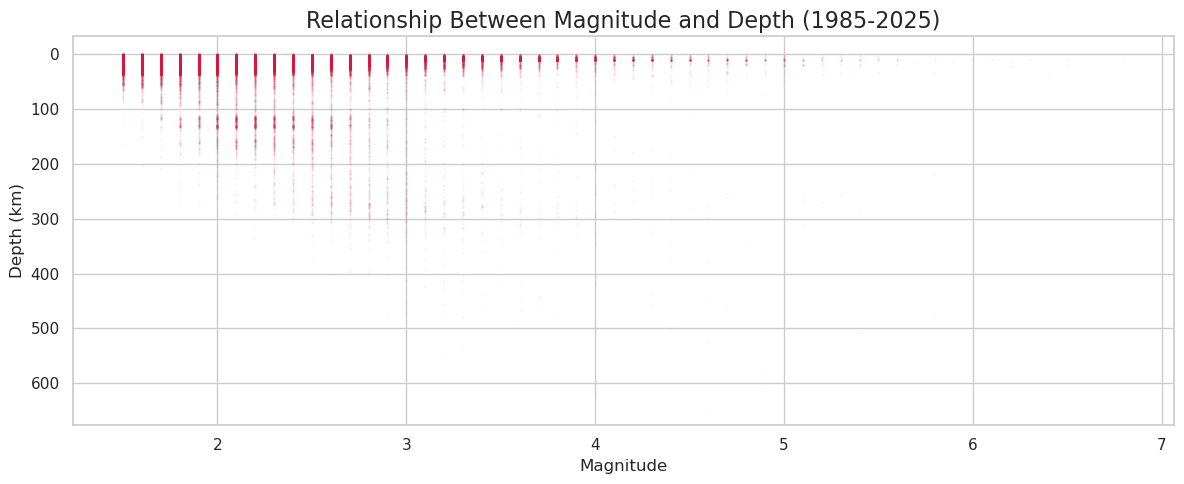

In [15]:
# Relationship Between Depth and Magnitude
plt.figure(figsize=(12, 5))
sns.scatterplot(data=df, x='magnitude', y='depth_km', alpha=0.05, s=2, color='crimson')
plt.gca().invert_yaxis()
plt.title('Relationship Between Magnitude and Depth (1985-2025)', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.tight_layout()
plt.show()

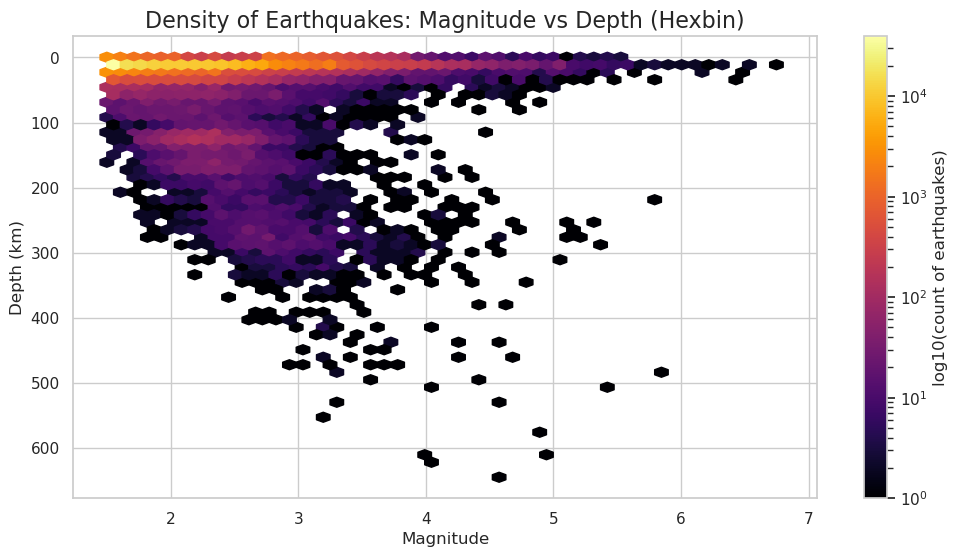

In [17]:
plt.figure(figsize=(12, 6))
hb = plt.hexbin(df['magnitude'], df['depth_km'], gridsize=50, cmap='inferno', mincnt=1, bins='log')
plt.colorbar(hb, label='log10(count of earthquakes)')
plt.gca().invert_yaxis()
plt.title('Density of Earthquakes: Magnitude vs Depth (Hexbin)', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

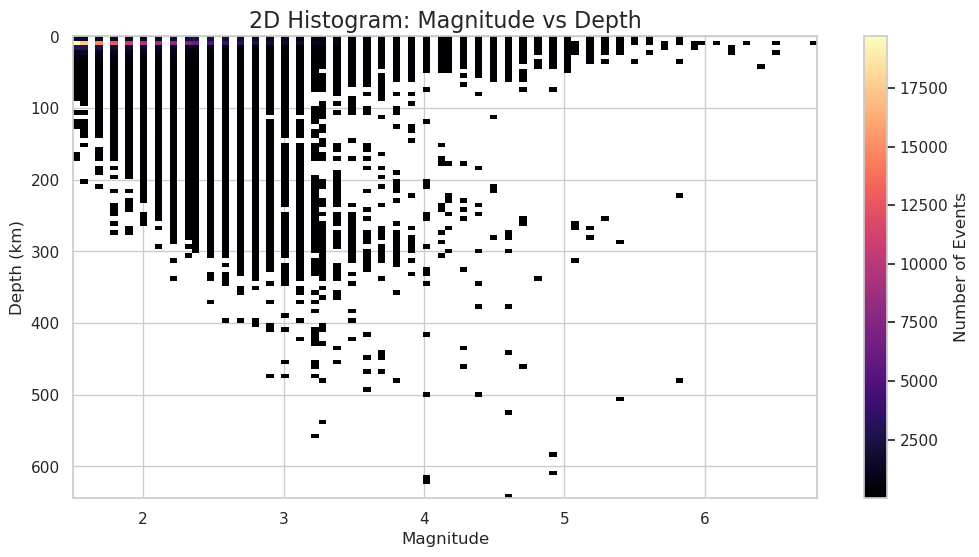

In [18]:
plot_df = df[['magnitude', 'depth_km']].dropna()
plt.figure(figsize=(12, 6))
plt.hist2d(plot_df['magnitude'], plot_df['depth_km'], bins=100, cmap='magma', cmin=1)
plt.colorbar(label='Number of Events')
plt.gca().invert_yaxis()
plt.title('2D Histogram: Magnitude vs Depth', fontsize=16)
plt.xlabel('Magnitude')
plt.ylabel('Depth (km)')
plt.show()

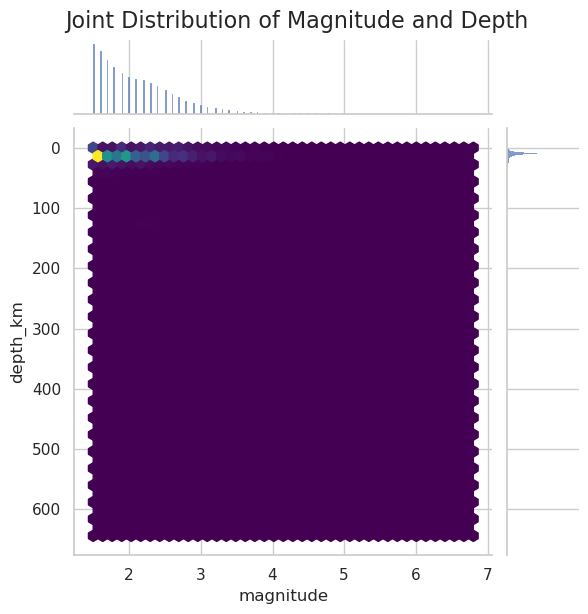

In [19]:
g = sns.jointplot(data=df, x='magnitude', y='depth_km', kind='hex', cmap='viridis', gridsize=40)
g.ax_joint.invert_yaxis()
g.fig.suptitle('Joint Distribution of Magnitude and Depth', y=1.02, fontsize=16)
plt.show()

/tmp/ipykernel_26793/702833299.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='mag_bin', y='depth_km', palette='coolwarm', showfliers=False)


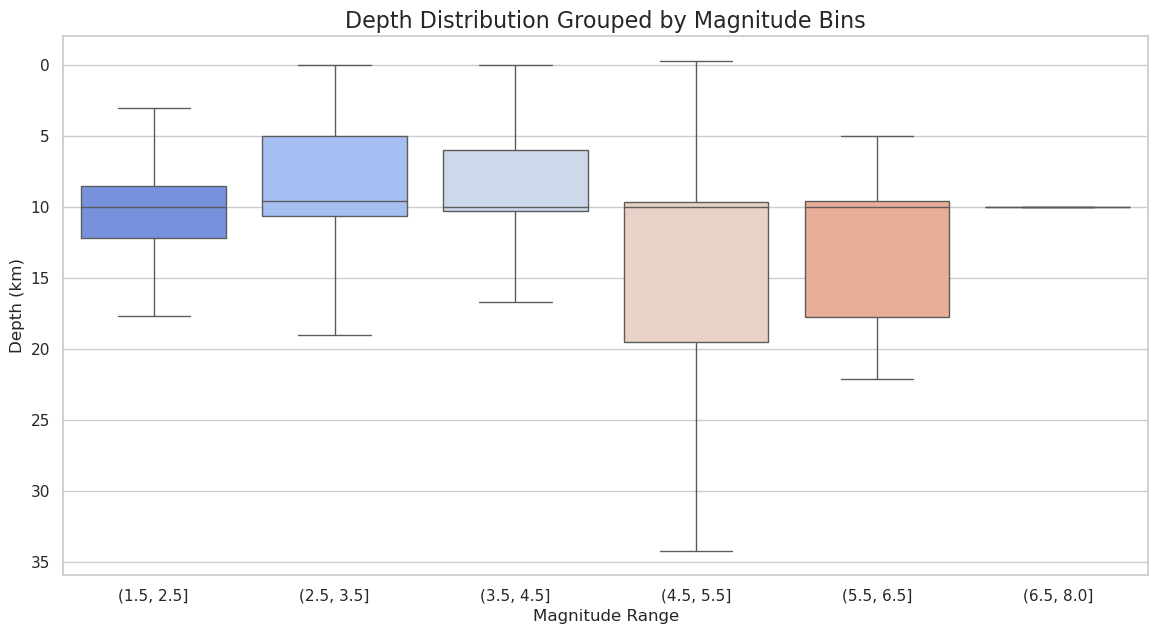

In [20]:
plt.figure(figsize=(14, 7))
df['mag_bin'] = pd.cut(df['magnitude'], bins=[1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 8.0])
sns.boxplot(data=df, x='mag_bin', y='depth_km', palette='coolwarm', showfliers=False)
plt.gca().invert_yaxis()
plt.title('Depth Distribution Grouped by Magnitude Bins', fontsize=16)
plt.xlabel('Magnitude Range')
plt.ylabel('Depth (km)')
plt.show()